In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

In [107]:
patients = pd.read_csv("../data/raw/patients.csv")
labs = pd.read_csv("../data/raw/labs.csv")
diagnoses = pd.read_csv("../data/raw/diagnoses.csv")
outcomes = pd.read_csv("../data/raw/outcomes.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [108]:
print("Patients:", patients.shape)
print("Labs:", labs.shape)
print("Diagnoses:", diagnoses.shape)
print("Outcomes:", outcomes.shape)

Patients: (5000, 9)
Labs: (30000, 5)
Diagnoses: (10, 2)
Outcomes: (3, 2)


In [109]:
print("PATIENTS")
display(patients.head())

print("LABS")
display(labs.head())

print("DIAGNOSES")
display(diagnoses.head())

print("OUTCOMES")
display(outcomes.head())

PATIENTS


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost
0,1,Aarav Sharma,89,F,10,2026-07-06,2026-07-16,3,7495
1,2,Vivaan Banerjee,41,M,6,2025-11-22,2025-11-24,1,3348
2,3,Aditya Malhotra,35,F,9,2025-01-22,2025-01-25,1,3504
3,4,Arjun Choudhary,73,M,9,2024-07-01,2024-07-10,3,7097
4,5,Rohan Kumar,45,M,10,2024-10-10,2024-10-13,1,3852


LABS


,LabID,PatientID,TestName,Result,NormalRange
0,1,1,Blood Pressure,130.04,90-120 mmHg
1,2,2,Blood Pressure,115.35,90-120 mmHg
2,3,3,Blood Pressure,118.02,90-120 mmHg
3,4,4,Blood Pressure,145.10,90-120 mmHg
4,5,5,Blood Pressure,118.26,90-120 mmHg


DIAGNOSES


,DiagnosisID,DiagnosisName
0,1,Hypertension
1,2,Diabetes
2,3,Heart Disease
3,4,Asthma
4,5,Stroke


OUTCOMES


,OutcomeID,OutcomeName
0,1,Recovered
1,2,Complicated
2,3,Deceased


In [110]:
print("========== PATIENTS ==========")
patients.info()

print("\n========== LABS ==========")
labs.info()

print("\n========== DIAGNOSES ==========")
diagnoses.info()

print("\n========== OUTCOMES ==========")
outcomes.info()

========== PATIENTS ==========
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   PatientID      5000 non-null   int64
 1   Name           5000 non-null   str  
 2   Age            5000 non-null   int64
 3   Gender         5000 non-null   str  
 4   DiagnosisID    5000 non-null   int64
 5   AdmissionDate  5000 non-null   str  
 6   DischargeDate  5000 non-null   str  
 7   OutcomeID      5000 non-null   int64
 8   TreatmentCost  5000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 509.7 KB

========== LABS ==========
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LabID        30000 non-null  int64  
 1   PatientID    30000 non-null  int64  
 2   TestName     30000 non-null  str    
 3   Result       30000 non-n

In [111]:
print("Patients summary:")
display(patients.describe(include="all"))

print("Labs summary:")
display(labs.describe(include="all"))

Patients summary:


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost
count,5000.000000,5000,5000.000000,5000,5000.000000,5000,5000,5000.000000,5000.000000
unique,NaN,20,NaN,2,NaN,995,999,NaN,NaN
top,NaN,Aarav Sharma,NaN,M,NaN,2024-04-13,2024-02-29,NaN,NaN
freq,NaN,250,NaN,2532,NaN,16,15,NaN,NaN
mean,2500.500000,NaN,57.720200,NaN,5.184200,NaN,NaN,1.450000,4564.650000
std,1443.520003,NaN,19.087828,NaN,2.907363,NaN,NaN,0.669021,1611.086688
min,1.000000,NaN,25.000000,NaN,1.000000,NaN,NaN,1.000000,1800.000000
25%,1250.750000,NaN,41.000000,NaN,3.000000,NaN,NaN,1.000000,3363.000000
50%,2500.500000,NaN,58.000000,NaN,5.000000,NaN,NaN,1.000000,3935.000000
75%,3750.250000,NaN,74.000000,NaN,8.000000,NaN,NaN,2.000000,5711.750000


Labs summary:


,LabID,PatientID,TestName,Result,NormalRange
count,30000.000000,30000.000000,30000,30000.000000,30000
unique,NaN,NaN,6,NaN,6
top,NaN,NaN,Blood Pressure,NaN,90-120 mmHg
freq,NaN,NaN,5000,NaN,5000
mean,15000.500000,2500.500000,NaN,76.420241,NaN
std,8660.398374,1443.399701,NaN,64.171024,NaN
min,1.000000,1.000000,NaN,0.490000,NaN
25%,7500.750000,1250.750000,NaN,14.380000,NaN
50%,15000.500000,2500.500000,NaN,57.335000,NaN
75%,22500.250000,3750.250000,NaN,126.212500,NaN


In [112]:
print("Missing values in Patients:")
display(patients.isnull().sum())

print("\nMissing values in Labs:")
display(labs.isnull().sum())

print("\nMissing values in Diagnoses:")
display(diagnoses.isnull().sum())

print("\nMissing values in Outcomes:")
display(outcomes.isnull().sum())

Missing values in Patients:


PatientID        0
Name             0
Age              0
Gender           0
DiagnosisID      0
AdmissionDate    0
DischargeDate    0
OutcomeID        0
TreatmentCost    0
dtype: int64


Missing values in Labs:


LabID          0
PatientID      0
TestName       0
Result         0
NormalRange    0
dtype: int64


Missing values in Diagnoses:


DiagnosisID      0
DiagnosisName    0
dtype: int64


Missing values in Outcomes:


OutcomeID      0
OutcomeName    0
dtype: int64

In [113]:
missing_percentage = (
    patients.isnull().sum()
    .div(len(patients))
    .mul(100)
    .sort_values(ascending=False)
)

display(missing_percentage)

PatientID        0.0
Name             0.0
Age              0.0
Gender           0.0
DiagnosisID      0.0
AdmissionDate    0.0
DischargeDate    0.0
OutcomeID        0.0
TreatmentCost    0.0
dtype: float64

In [114]:
print("Duplicate patient rows:", patients.duplicated().sum())
print("Duplicate lab rows:", labs.duplicated().sum())
print("Duplicate diagnosis rows:", diagnoses.duplicated().sum())
print("Duplicate outcome rows:", outcomes.duplicated().sum())

Duplicate patient rows: 0
Duplicate lab rows: 0
Duplicate diagnosis rows: 0
Duplicate outcome rows: 0


In [115]:
print("Duplicate Patient IDs:",
      patients["PatientID"].duplicated().sum())

print("Duplicate Lab IDs:",
      labs["LabID"].duplicated().sum())

print("Duplicate Diagnosis IDs:",
      diagnoses["DiagnosisID"].duplicated().sum())

print("Duplicate Outcome IDs:",
      outcomes["OutcomeID"].duplicated().sum())

Duplicate Patient IDs: 0
Duplicate Lab IDs: 0
Duplicate Diagnosis IDs: 0
Duplicate Outcome IDs: 0


In [116]:
print("Total patients:", patients["PatientID"].nunique())
print("Patients with lab records:", labs["PatientID"].nunique())

missing_lab_patients = (
    set(patients["PatientID"]) -
    set(labs["PatientID"])
)

print("Patients without lab records:",
      len(missing_lab_patients))

Total patients: 5000
Patients with lab records: 5000
Patients without lab records: 0


In [117]:
invalid_diagnosis_ids = (
    set(patients["DiagnosisID"]) -
    set(diagnoses["DiagnosisID"])
)

print("Invalid Diagnosis IDs:")
print(invalid_diagnosis_ids)

Invalid Diagnosis IDs:
set()


In [118]:
invalid_outcome_ids = (
    set(patients["OutcomeID"]) -
    set(outcomes["OutcomeID"])
)

print("Invalid Outcome IDs:")
print(invalid_outcome_ids)

Invalid Outcome IDs:
set()


In [119]:
patients["AdmissionDate"] = pd.to_datetime(
    patients["AdmissionDate"],
    errors="coerce"
)

patients["DischargeDate"] = pd.to_datetime(
    patients["DischargeDate"],
    errors="coerce"
)

print(patients[["AdmissionDate", "DischargeDate"]].dtypes)

AdmissionDate    datetime64[us]
DischargeDate    datetime64[us]
dtype: object


In [120]:
print(
    "Invalid Admission Dates:",
    patients["AdmissionDate"].isna().sum()
)

print(
    "Invalid Discharge Dates:",
    patients["DischargeDate"].isna().sum()
)

Invalid Admission Dates: 0
Invalid Discharge Dates: 0


In [121]:
patients["LengthOfStay"] = (
    patients["DischargeDate"] -
    patients["AdmissionDate"]
).dt.days

display(
    patients[
        ["PatientID", "AdmissionDate",
         "DischargeDate", "LengthOfStay"]
    ].head()
)

,PatientID,AdmissionDate,DischargeDate,LengthOfStay
0,1,2026-07-06,2026-07-16,10
1,2,2025-11-22,2025-11-24,2
2,3,2025-01-22,2025-01-25,3
3,4,2024-07-01,2024-07-10,9
4,5,2024-10-10,2024-10-13,3


In [122]:
print(
    "Negative Length of Stay:",
    (patients["LengthOfStay"] < 0).sum()
)

print(
    "Zero Length of Stay:",
    (patients["LengthOfStay"] == 0).sum()
)

Negative Length of Stay: 0
Zero Length of Stay: 0


In [123]:
print(patients["Gender"].value_counts())

Gender
M    2532
F    2468
Name: count, dtype: int64


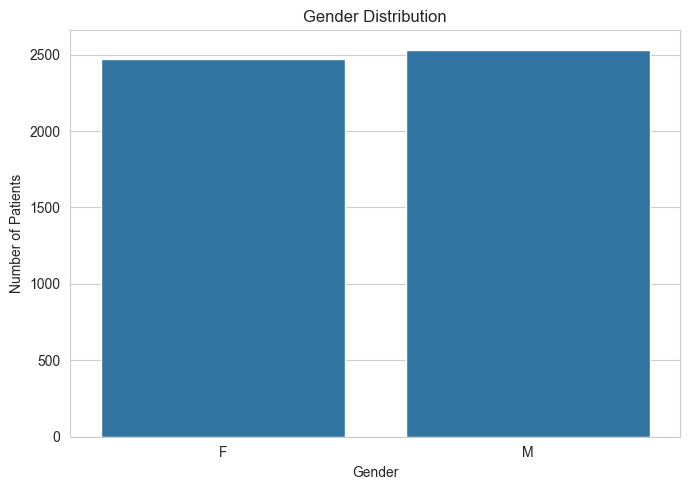

In [124]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=patients,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

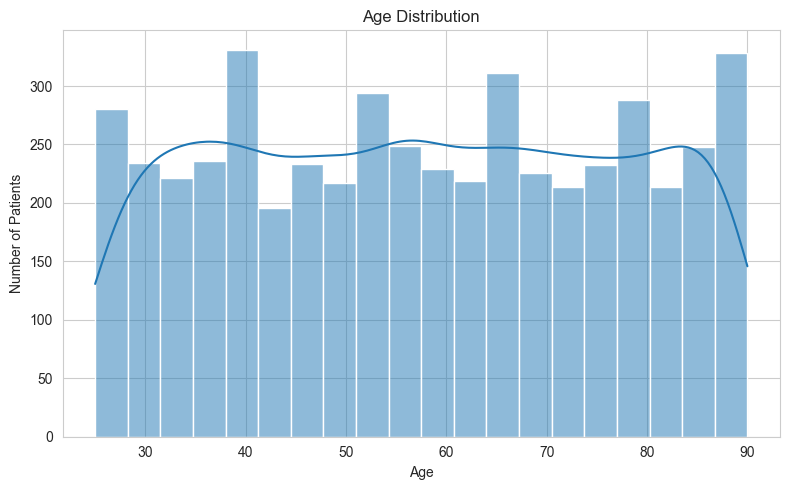

In [125]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=patients,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [126]:
diagnosis_counts = patients["DiagnosisID"].value_counts().sort_index()

display(diagnosis_counts)

DiagnosisID
1     625
2     526
3     685
4     449
5     399
6     459
7     492
8     500
9     450
10    415
Name: count, dtype: int64

In [127]:
eda_df = patients.merge(
    diagnoses,
    on="DiagnosisID",
    how="left"
)

display(
    eda_df[
        ["PatientID", "DiagnosisID", "DiagnosisName"]
    ].head()
)

,PatientID,DiagnosisID,DiagnosisName
0,1,10,Liver Disease
1,2,6,COPD
2,3,9,Kidney Disease
3,4,9,Kidney Disease
4,5,10,Liver Disease


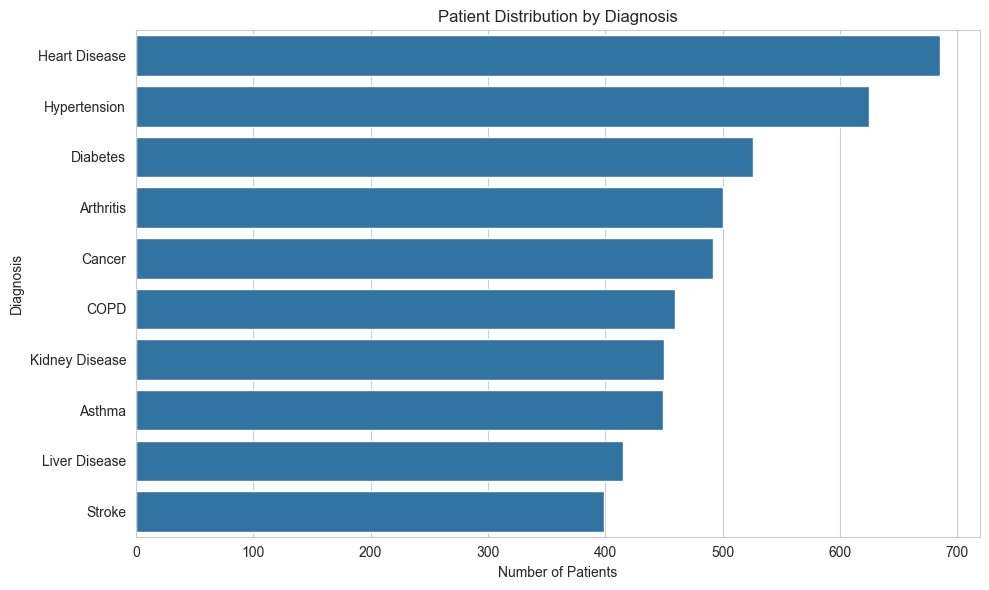

In [128]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=eda_df,
    y="DiagnosisName",
    order=eda_df["DiagnosisName"].value_counts().index
)

plt.title("Patient Distribution by Diagnosis")
plt.xlabel("Number of Patients")
plt.ylabel("Diagnosis")

plt.tight_layout()
plt.show()

In [129]:
eda_df = eda_df.merge(
    outcomes,
    on="OutcomeID",
    how="left"
)

display(
    eda_df["OutcomeName"].value_counts()
)

OutcomeName
Recovered      3250
Complicated    1250
Deceased        500
Name: count, dtype: int64

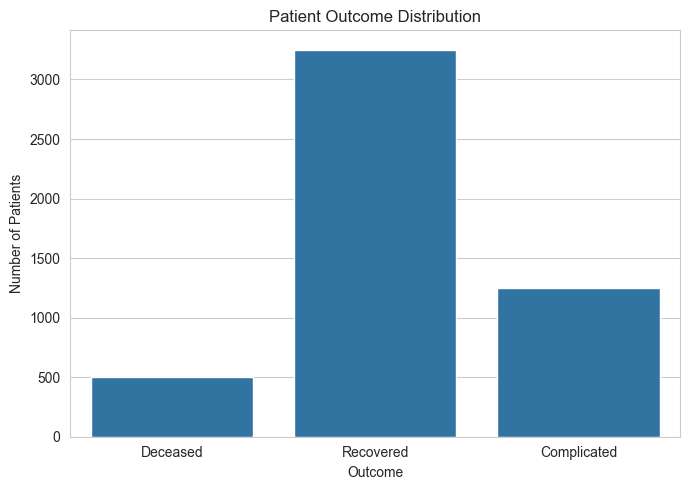

In [130]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="OutcomeName"
)

plt.title("Patient Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

In [131]:
outcome_percentage = (
    eda_df["OutcomeName"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(outcome_percentage)

OutcomeName
Recovered      65.0
Complicated    25.0
Deceased       10.0
Name: proportion, dtype: float64

In [132]:
print(labs["TestName"].value_counts())

TestName
Blood Pressure    5000
Blood Sugar       5000
Cholesterol       5000
Creatinine        5000
Hemoglobin        5000
Vitamin D         5000
Name: count, dtype: int64


In [133]:
lab_summary = labs.groupby(
    "TestName"
)["Result"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(lab_summary.round(2))

,count,mean,median,std,min,max
TestName,,,,,,
Blood Pressure,5000,124.06,123.94,8.33,97.97,155.34
Blood Sugar,5000,105.90,104.23,15.78,64.27,162.66
Cholesterol,5000,175.91,174.66,16.20,129.81,237.76
Creatinine,5000,0.97,0.92,0.26,0.49,1.97
Hemoglobin,5000,14.30,14.38,0.79,11.41,16.86
Vitamin D,5000,37.38,37.39,3.72,21.99,50.40


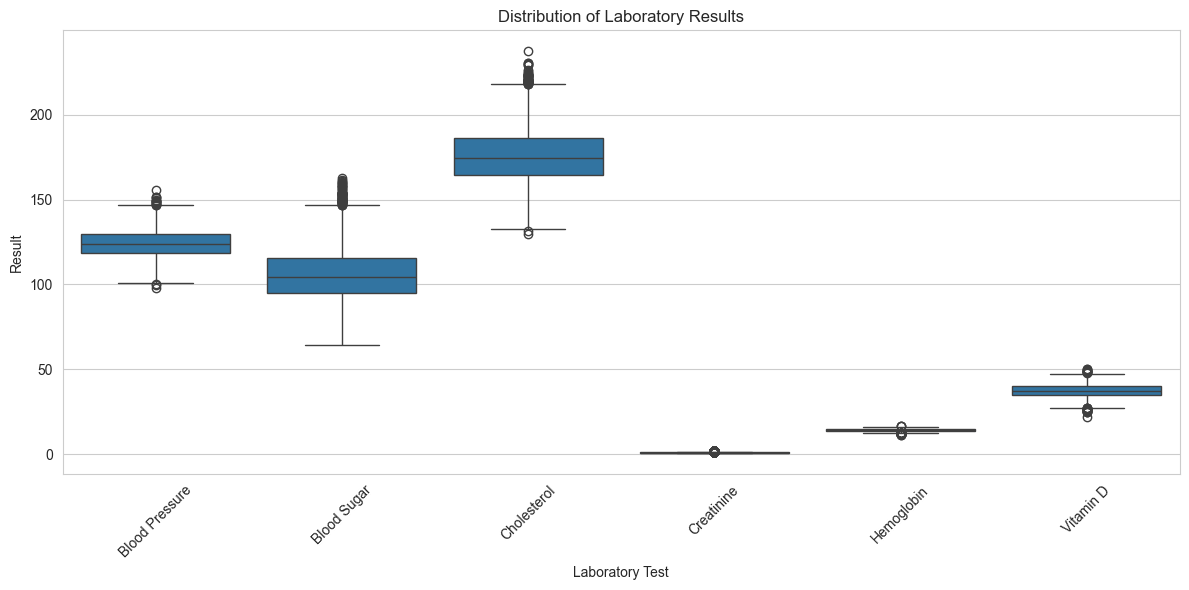

In [134]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=labs,
    x="TestName",
    y="Result"
)

plt.title("Distribution of Laboratory Results")
plt.xlabel("Laboratory Test")
plt.ylabel("Result")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [135]:
labs_wide = labs.pivot(
    index="PatientID",
    columns="TestName",
    values="Result"
).reset_index()

display(labs_wide.head())

TestName,PatientID,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
0,1,130.04,135.70,204.00,1.03,13.72,33.53
1,2,115.35,93.75,160.33,0.85,15.22,42.17
2,3,118.02,95.16,136.25,1.37,14.05,41.54
3,4,145.10,126.79,180.61,1.72,12.48,27.82
4,5,118.26,106.44,182.04,0.86,14.64,37.39


In [136]:
labs_wide = labs.pivot(
    index="PatientID",
    columns="TestName",
    values="Result"
).reset_index()

display(labs_wide.head())

TestName,PatientID,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
0,1,130.04,135.70,204.00,1.03,13.72,33.53
1,2,115.35,93.75,160.33,0.85,15.22,42.17
2,3,118.02,95.16,136.25,1.37,14.05,41.54
3,4,145.10,126.79,180.61,1.72,12.48,27.82
4,5,118.26,106.44,182.04,0.86,14.64,37.39


In [137]:
print("Lab wide shape:", labs_wide.shape)

Lab wide shape: (5000, 7)


In [138]:
combined_df = patients.merge(
    diagnoses,
    on="DiagnosisID",
    how="left"
)

combined_df = combined_df.merge(
    outcomes,
    on="OutcomeID",
    how="left"
)

combined_df = combined_df.merge(
    labs_wide,
    on="PatientID",
    how="left"
)

print("Combined dataset shape:", combined_df.shape)

display(combined_df.head())

Combined dataset shape: (5000, 18)


,PatientID,Name,Age,Gender,DiagnosisID,AdmissionDate,DischargeDate,OutcomeID,TreatmentCost,LengthOfStay,DiagnosisName,OutcomeName,Blood Pressure,Blood Sugar,Cholesterol,Creatinine,Hemoglobin,Vitamin D
0,1,Aarav Sharma,89,F,10,2026-07-06,2026-07-16,3,7495,10,Liver Disease,Deceased,130.04,135.70,204.00,1.03,13.72,33.53
1,2,Vivaan Banerjee,41,M,6,2025-11-22,2025-11-24,1,3348,2,COPD,Recovered,115.35,93.75,160.33,0.85,15.22,42.17
2,3,Aditya Malhotra,35,F,9,2025-01-22,2025-01-25,1,3504,3,Kidney Disease,Recovered,118.02,95.16,136.25,1.37,14.05,41.54
3,4,Arjun Choudhary,73,M,9,2024-07-01,2024-07-10,3,7097,9,Kidney Disease,Deceased,145.10,126.79,180.61,1.72,12.48,27.82
4,5,Rohan Kumar,45,M,10,2024-10-10,2024-10-13,1,3852,3,Liver Disease,Recovered,118.26,106.44,182.04,0.86,14.64,37.39


In [139]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   PatientID       5000 non-null   int64         
 1   Name            5000 non-null   str           
 2   Age             5000 non-null   int64         
 3   Gender          5000 non-null   str           
 4   DiagnosisID     5000 non-null   int64         
 5   AdmissionDate   5000 non-null   datetime64[us]
 6   DischargeDate   5000 non-null   datetime64[us]
 7   OutcomeID       5000 non-null   int64         
 8   TreatmentCost   5000 non-null   int64         
 9   LengthOfStay    5000 non-null   int64         
 10  DiagnosisName   5000 non-null   str           
 11  OutcomeName     5000 non-null   str           
 12  Blood Pressure  5000 non-null   float64       
 13  Blood Sugar     5000 non-null   float64       
 14  Cholesterol     5000 non-null   float64       
 15  Creatinine     

In [140]:
missing_combined = combined_df.isnull().sum()

display(
    missing_combined[
        missing_combined > 0
    ]
)

Series([], dtype: int64)

In [141]:
diagnosis_outcome = pd.crosstab(
    combined_df["DiagnosisName"],
    combined_df["OutcomeName"]
)

display(diagnosis_outcome)

OutcomeName,Complicated,Deceased,Recovered
DiagnosisName,,,
Arthritis,94,10,396
Asthma,89,9,351
COPD,118,33,308
Cancer,159,101,232
Diabetes,130,37,359
Heart Disease,190,111,384
Hypertension,133,13,479
Kidney Disease,113,74,263
Liver Disease,100,42,273


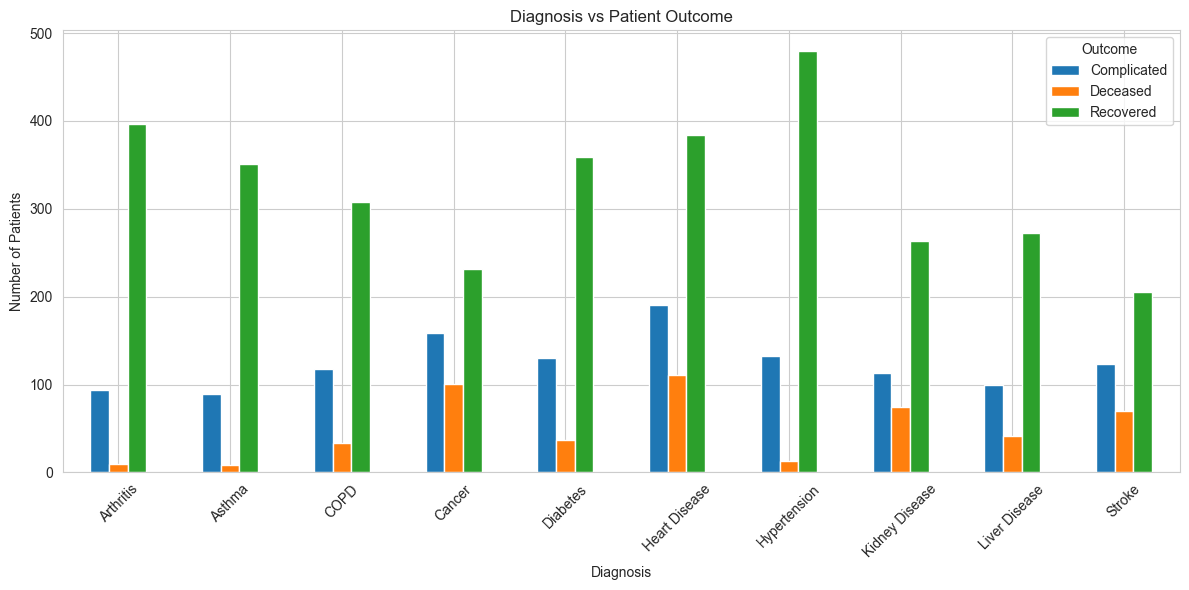

In [142]:
diagnosis_outcome.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Diagnosis vs Patient Outcome")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)
plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

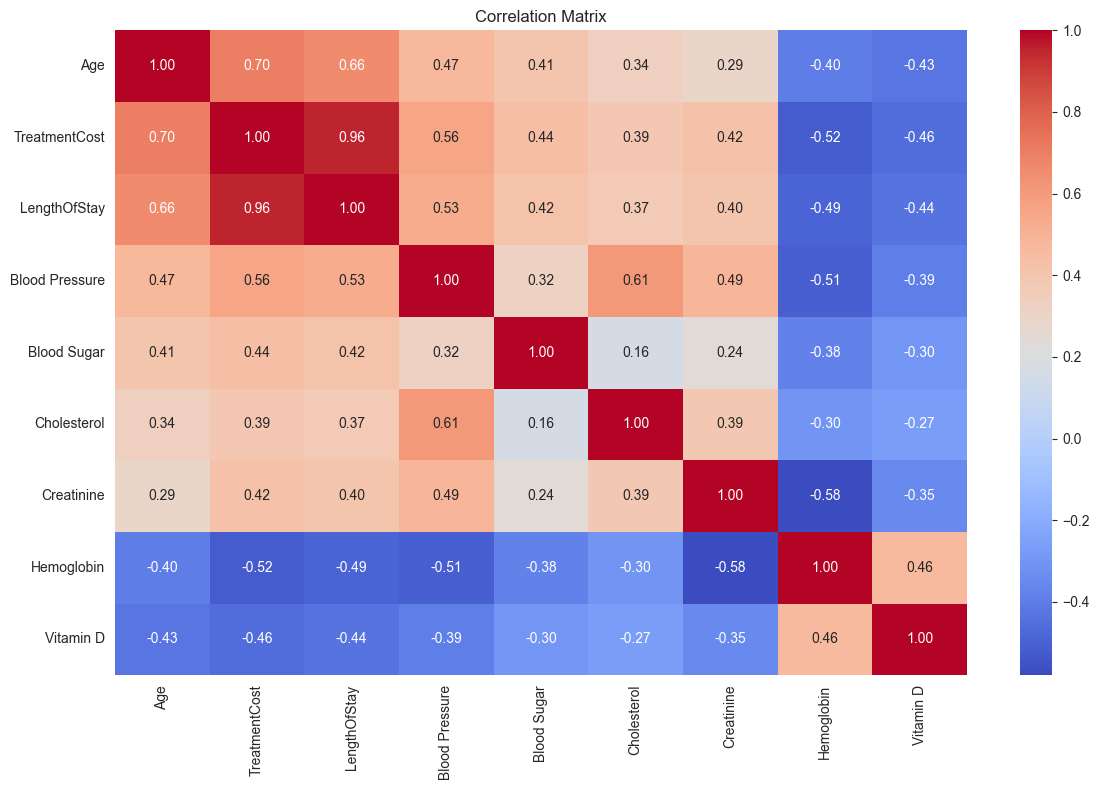

In [143]:
numeric_columns = [
    "Age",
    "TreatmentCost",
    "LengthOfStay",
    "Blood Pressure",
    "Blood Sugar",
    "Cholesterol",
    "Creatinine",
    "Hemoglobin",
    "Vitamin D"
]

correlation = combined_df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

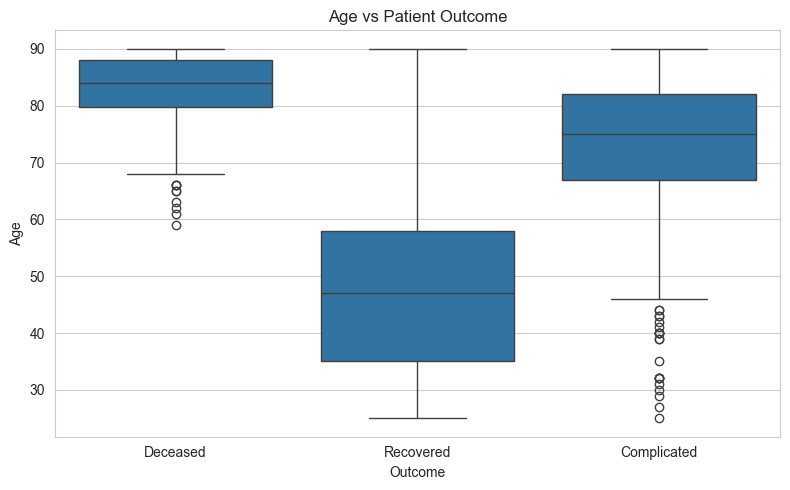

In [144]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_df,
    x="OutcomeName",
    y="Age"
)

plt.title("Age vs Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

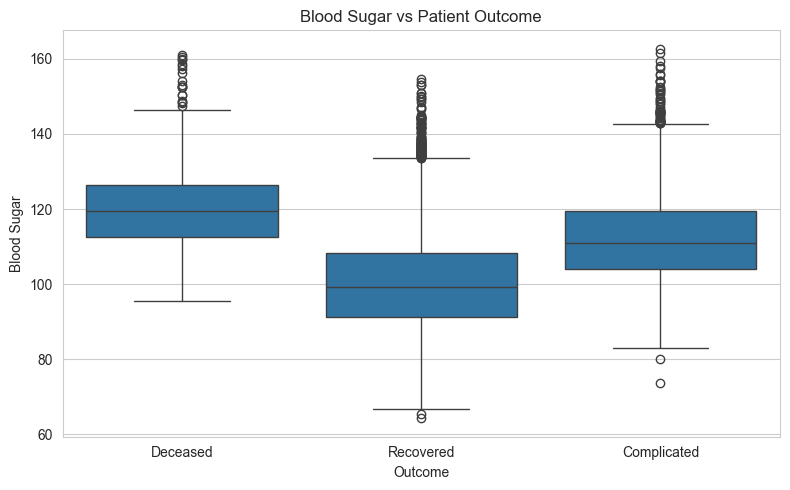

In [145]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_df,
    x="OutcomeName",
    y="Blood Sugar"
)

plt.title("Blood Sugar vs Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Blood Sugar")

plt.tight_layout()
plt.show()

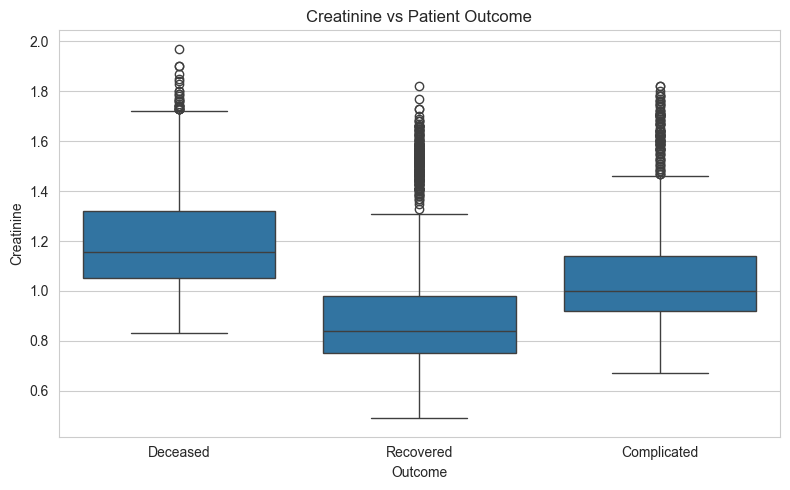

In [146]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_df,
    x="OutcomeName",
    y="Creatinine"
)

plt.title("Creatinine vs Patient Outcome")
plt.xlabel("Outcome")
plt.ylabel("Creatinine")

plt.tight_layout()
plt.show()

In [147]:
print("========== FINAL DATASET ==========")

print("Rows:", combined_df.shape[0])
print("Columns:", combined_df.shape[1])

print("\nDuplicates:")
print(combined_df.duplicated().sum())

print("\nMissing Values:")
display(combined_df.isnull().sum())

print("\nData Types:")
display(combined_df.dtypes)

========== FINAL DATASET ==========
Rows: 5000
Columns: 18

Duplicates:
0

Missing Values:


PatientID         0
Name              0
Age               0
Gender            0
DiagnosisID       0
AdmissionDate     0
DischargeDate     0
OutcomeID         0
TreatmentCost     0
LengthOfStay      0
DiagnosisName     0
OutcomeName       0
Blood Pressure    0
Blood Sugar       0
Cholesterol       0
Creatinine        0
Hemoglobin        0
Vitamin D         0
dtype: int64


Data Types:


PatientID                  int64
Name                         str
Age                        int64
Gender                       str
DiagnosisID                int64
AdmissionDate     datetime64[us]
DischargeDate     datetime64[us]
OutcomeID                  int64
TreatmentCost              int64
LengthOfStay               int64
DiagnosisName                str
OutcomeName                  str
Blood Pressure           float64
Blood Sugar              float64
Cholesterol              float64
Creatinine               float64
Hemoglobin               float64
Vitamin D                float64
dtype: object

In [148]:
output_path = "../data/processed/healthcare_cleaned.csv"

combined_df.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
../data/processed/healthcare_cleaned.csv
